In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
dataset_path = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"

train_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_path,
    "Train.csv"
)

test_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_path,
    "Test.csv"
)

In [3]:
cache_path = kagglehub.dataset_download(dataset_path)

def get_hog(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros(324)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (32, 32))
    return hog(img, orientations=9, pixels_per_cell=(8, 8), 
               cells_per_block=(2, 2), visualize=False, feature_vector=True)

In [4]:
X = []
y = []

for i, row in train_df.head(5000).iterrows():
    path = os.path.join(cache_path, row['Path'])
    X.append(get_hog(path))
    y.append(row['ClassId'])

X = np.array(X)
y = np.array(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=10, batch_size=64, 
                    validation_data=(X_test, y_test), verbose=1)

/home/mlguest/miniforge3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1788705964.960286 1016324 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788705965.037328 1016324 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1788705965.038099 1016324 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compu

Epoch 1/10


I0000 00:00:1788705965.895093 1016408 service.cc:153] XLA service 0x7b7e94033630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788705965.895107 1016408 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.25.0)
I0000 00:00:1788705965.907122 1016408 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788705965.976991 1016408 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1788705966.003988 1016408 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1408__.15
I0000 00:00:1788705966.035830 1016408 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead

 1/63 ━━━━━━━━━━━━━━━━━━━━ 3:33 3s/step - accuracy: 0.0000e+00 - loss: 4.1331

I0000 00:00:1788705968.930634 1016408 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1788705969.061498 1016411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1408__.15
I0000 00:00:1788705969.210922 1016411 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788705969.688600 1016411 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788705970.025572 1016626 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6358 - loss: 1.2360    

I0000 00:00:1788705971.977849 1016411 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788705972.582963 1016863 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1788705972.648300 1016851 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 140 bytes spill stores, 140 bytes spill loads

I0000 00:00:1788705972.733762 1016849 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 156 bytes spill stores, 292 bytes spill loads

I0000 00:00:1788705973.255098 1016408 dot_search_space.cc:240] All configs were filtered out becaus

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.6357 - loss: 1.2360 - val_accuracy: 0.8620 - val_loss: 0.3793
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8432 - loss: 0.4041 - val_accuracy: 0.8910 - val_loss: 0.2753
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8855 - loss: 0.2954 - val_accuracy: 0.9130 - val_loss: 0.2343
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9060 - loss: 0.2409 - val_accuracy: 0.9220 - val_loss: 0.2128
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9222 - loss: 0.2008 - val_accuracy: 0.9290 - val_loss: 0.1940
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9277 - loss: 0.1813 - val_accuracy: 0.9260 - val_loss: 0.1904
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9448 - loss: 0.1588 - val_accuracy: 0.9310 - val_loss: 0.1793
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9410 - loss: 0.1502 - val_accuracy: 0.9310 - val_loss: 0.1856
Ep

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

I0000 00:00:1788705975.388345 1016408 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788705975.802453 1017682 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 264 bytes spill stores, 264 bytes spill loads

I0000 00:00:1788705975.814732 1017683 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads

I0000 00:00:1788705975.885652 1017669 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads



In [9]:
print(f"Accuracy: {test_acc:.4f}")

Accuracy: 0.9380


In [13]:
def load_image_for_display(img_path, size=(64, 64)):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((*size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

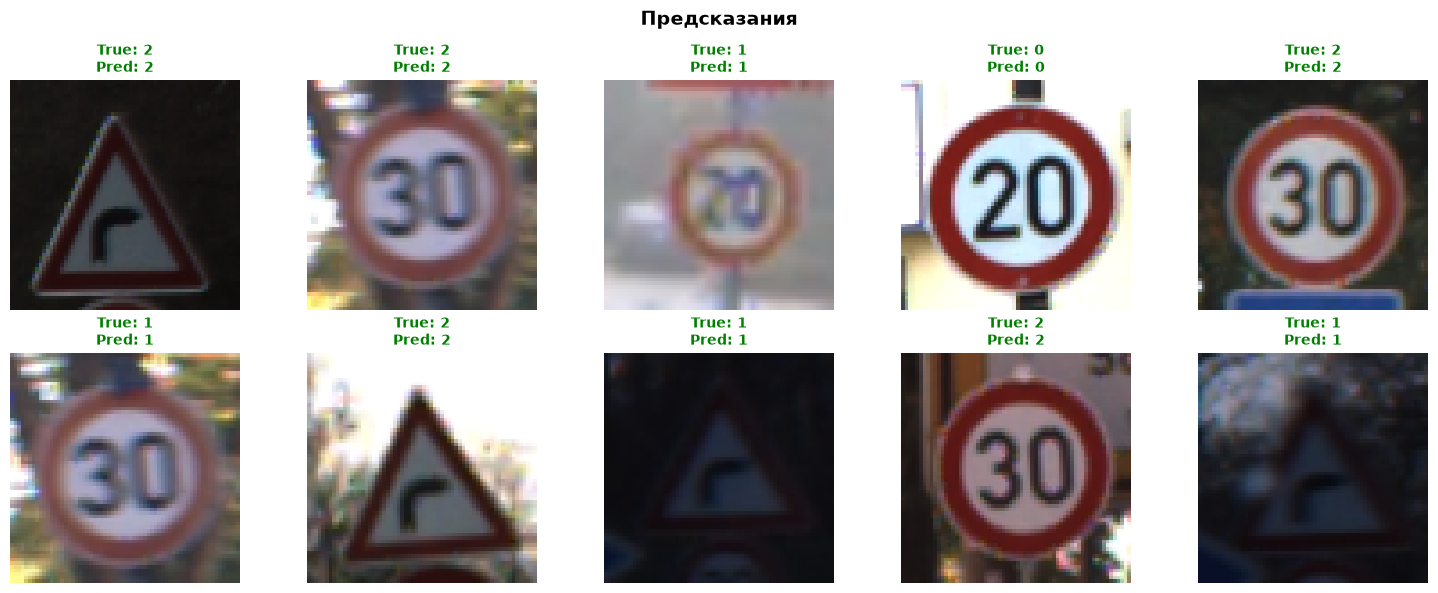

In [15]:
plt.figure(figsize=(15, 6))

random_indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i+1)
    img_path = os.path.join(cache_path, train_df.iloc[idx]['Path'])
    img = load_image_for_display(img_path)
    
    plt.imshow(img)
    
    true_label = y_test[idx]
    pred_label = y_pred_classes[idx]
    color = 'green' if pred_label == true_label else 'red'
    
    plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=10, color=color, fontweight='bold')
    plt.axis('off')

plt.suptitle('Предсказания', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()